In [1]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [2]:
import healpix_geo
import numpy as np
import matplotlib.pyplot as plt
from cdshealpix import to_ring
from healpix_analyse.powerspectra import powerspectra

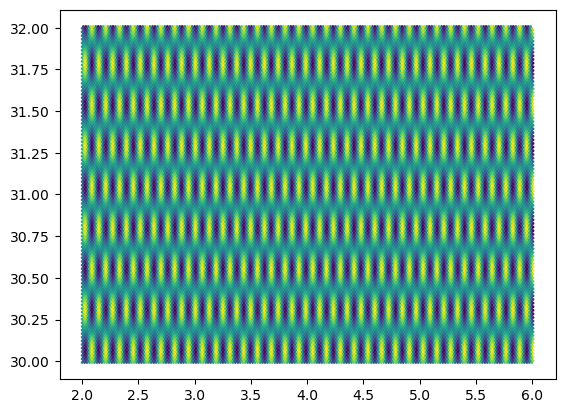

In [14]:
level = 12
ellipsoid = 'WGS84'
indexing_scheme = 'ring' # 'ring' or 'nested'
definition = 20

# Coverage box
lon_min, lon_max = 2.0, 6.0
lat_min, lat_max = 30.0, 32.0

cell_ids, _, _ = healpix_geo.nested.zone_coverage(bbox=(lon_min,lat_min,lon_max,lat_max),
                                                  depth=level, 
                                                  ellipsoid=ellipsoid)

if indexing_scheme == 'ring': 
    cell_ids = to_ring(cell_ids, depth=level)
    lon, lat = healpix_geo.ring.healpix_to_lonlat(cell_ids, level, ellipsoid=ellipsoid)
elif indexing_scheme == 'nested':
    lon, lat = healpix_geo.nested.healpix_to_lonlat(cell_ids, level, ellipsoid=ellipsoid)
else:
    raise NotImplementedError("For now, indexing_scheme must be 'ring' or 'nested'")

data = np.cos(1024*lon/definition) * np.sin(256*lat/definition) + 1

plt.scatter(lon, lat, c=data, s=1)

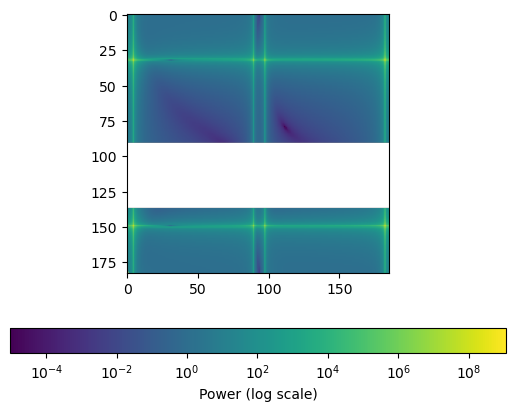

In [15]:
nu, cl = powerspectra(cell_ids, level, data, indexing_scheme=indexing_scheme, plot_2D_fft=True)

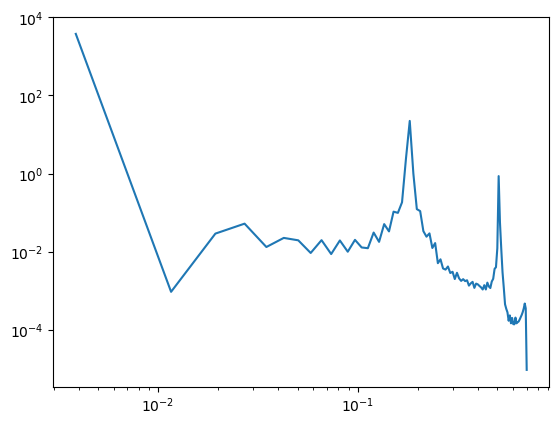

In [16]:
plt.plot(nu, cl)
plt.yscale('log')
plt.xscale('log')

In [17]:
lats = np.unique(lat)
lons = np.unique(lon)

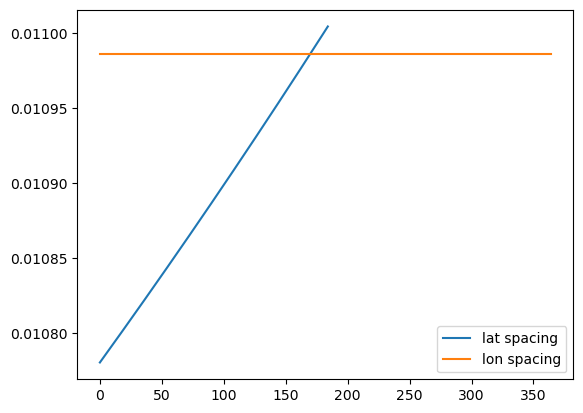

In [18]:
plt.plot(np.diff(lats), label='lat spacing')
plt.plot(np.diff(lons), label='lon spacing')
plt.legend()
plt.show()

In [11]:
import torch
import numpy as np
from healpix_analyse.nufft_shift import nufft_shifted_fft

x,y=np.meshgrid(np.arange(128),np.arange(128))
xshift=x+(np.arange(128)%2)*0.5

a=0.5
data=np.cos(x/a)*np.sin(y/a)
data_shift=torch.tensor(np.cos(xshift/a)*np.sin(y/a))

# Décalages fractionnaires (en échantillons, pas forcément entiers)
dtheta = torch.tensor([(k%2)*0.5 for k in range(128)])

# FFT alignée sur 0
F  = resample_then_fft(data_shift, dtheta)   # → [8, 512] complexe
F2 = np.fft.fft(data)
F3 = np.fft.fft(data_shift)

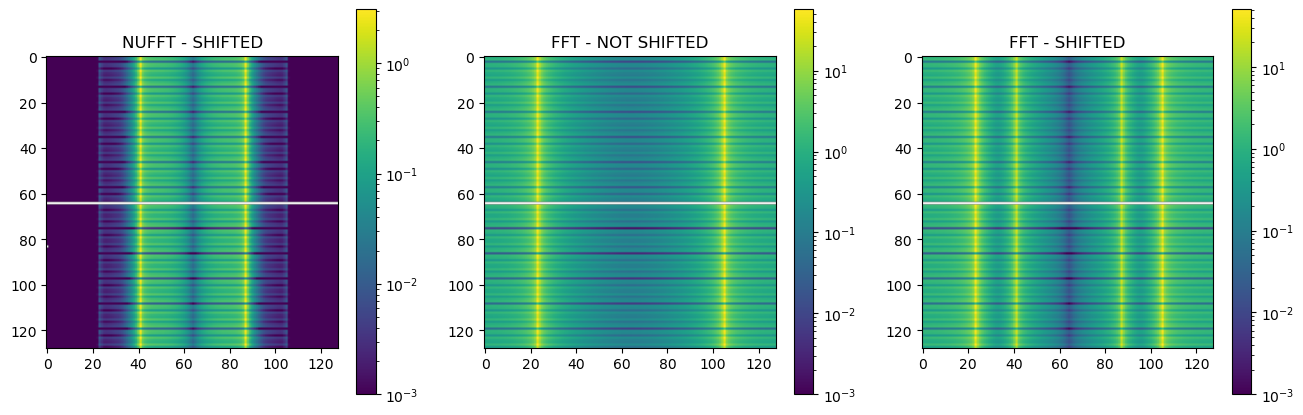

In [12]:

import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.title('NUFFT - SHIFTED')
plt.imshow(np.fft.fftshift(abs(F)),norm='log',vmin=1E-3)
plt.colorbar()
plt.subplot(1,3,2)
plt.title('FFT - NOT SHIFTED')
plt.imshow(np.fft.fftshift(abs(F2)),norm='log',vmin=1E-3)
plt.colorbar()
plt.subplot(1,3,3)
plt.title('FFT - SHIFTED')
plt.imshow(np.fft.fftshift(abs(F3)),norm='log',vmin=1E-3)
plt.colorbar()

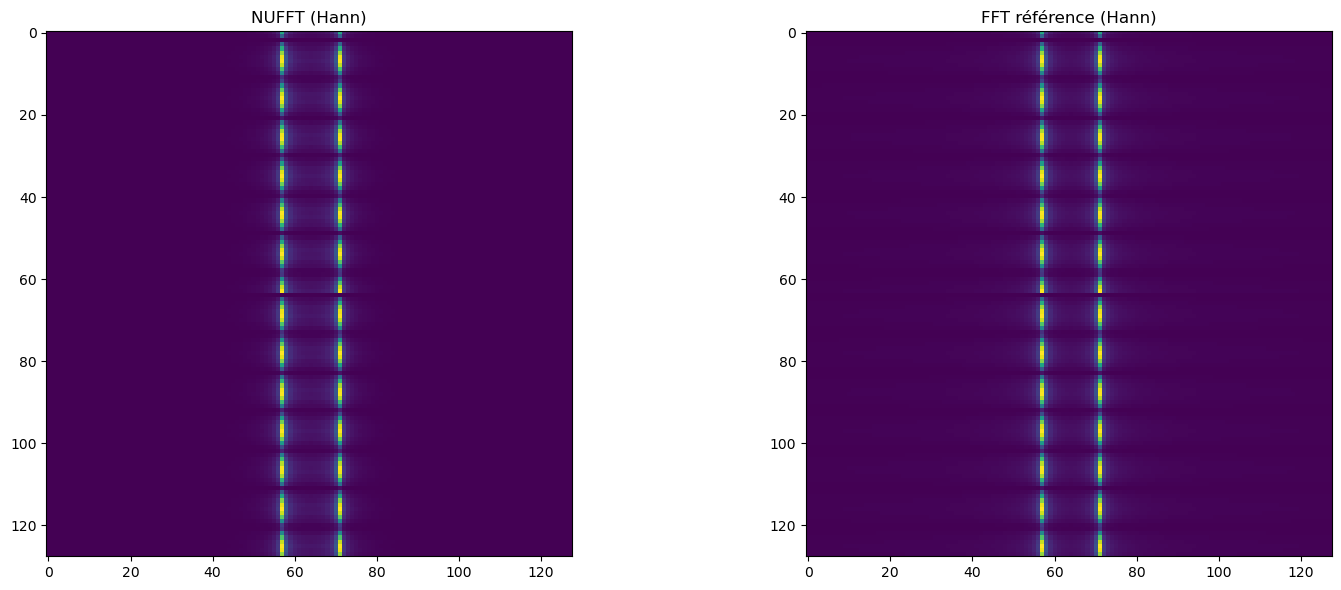

In [1]:
import torch
import numpy as np
from healpix_analyse.nufft_shift import resample_then_fft   # ← nouvelle fonction

x, y = np.meshgrid(np.arange(128), np.arange(128))
xshift = x + (np.arange(128)[:, None] % 2) * 0.5

data       = np.cos(x/3) * np.sin(y/3)
data_shift = torch.tensor(np.cos(xshift/3) * np.sin(y/3))

dtheta = torch.tensor([(k % 2) * 0.5 for k in range(128)])

# ── NUFFT + FFT de référence ─────────────────────────────────────────────
F  = resample_then_fft(data_shift, dtheta)
F2 = np.fft.fft(data)

import matplotlib.pyplot as plt
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.title("NUFFT (Hann)")
plt.imshow(np.fft.fftshift(abs(F.numpy())))
plt.subplot(1, 2, 2)
plt.title("FFT référence (Hann)")
plt.imshow(np.fft.fftshift(abs(F2)))
plt.tight_layout()
plt.show()